In [19]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

#params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h', 'n_s', 'sigma8_m'][1:-1]
params_toplot = ['omega_b', 'omega_cdm', 'sigma8_m', 'h', 'n_s']

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue

def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

plot_dir = Path('validation_redshift_smearing')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

### LRG3

Removed no burn in
Removed no burn in
Removed no burn in


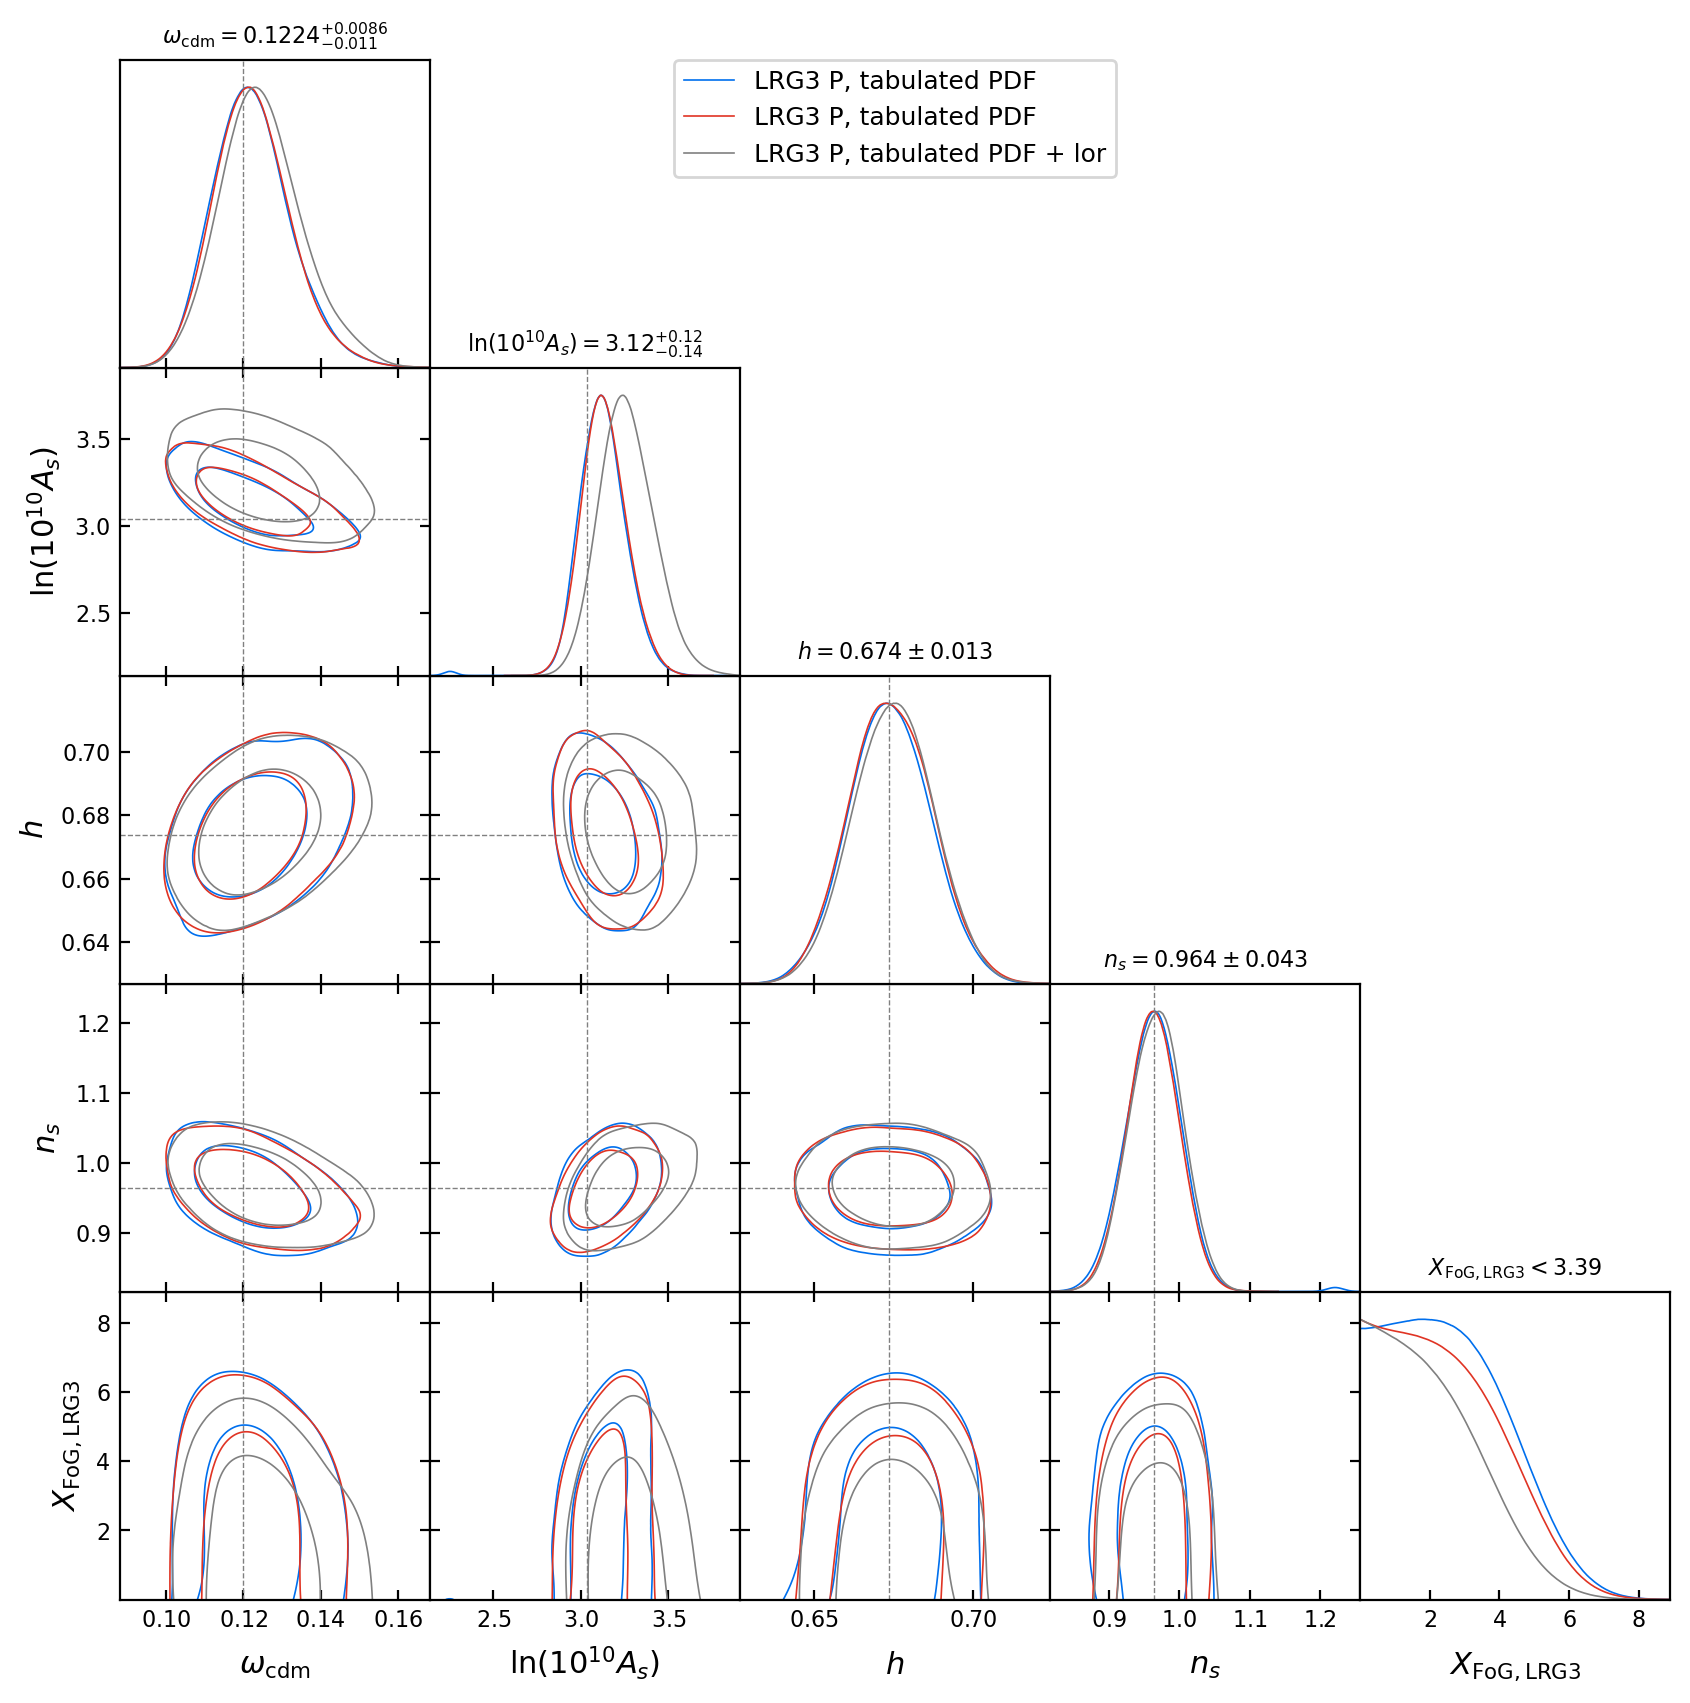

In [16]:
# P0 < 0.30, P2 < 0.20
dirname = Path('/pscratch/sd/a/adematti/fits_redshift_smearing/abacus-hf-dr2-v2-altmtl')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_LRG3-S2-dd5861c0/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('LRG3 P, tabulated PDF')
samples.append(read_samples([dirname / f'cosmo-base_LRG3-S2-rs-pdf-be2e2299/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('LRG3 P, tabulated PDF')
samples.append(read_samples([dirname / f'cosmo-base_LRG3-S2-rs-pdf-lor-37a53648/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('LRG3 P, tabulated PDF + lor')
plotting.plot_triangle(samples, params=params_toplot + ['LRG3.X_FoG'], title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

Removed no burn in


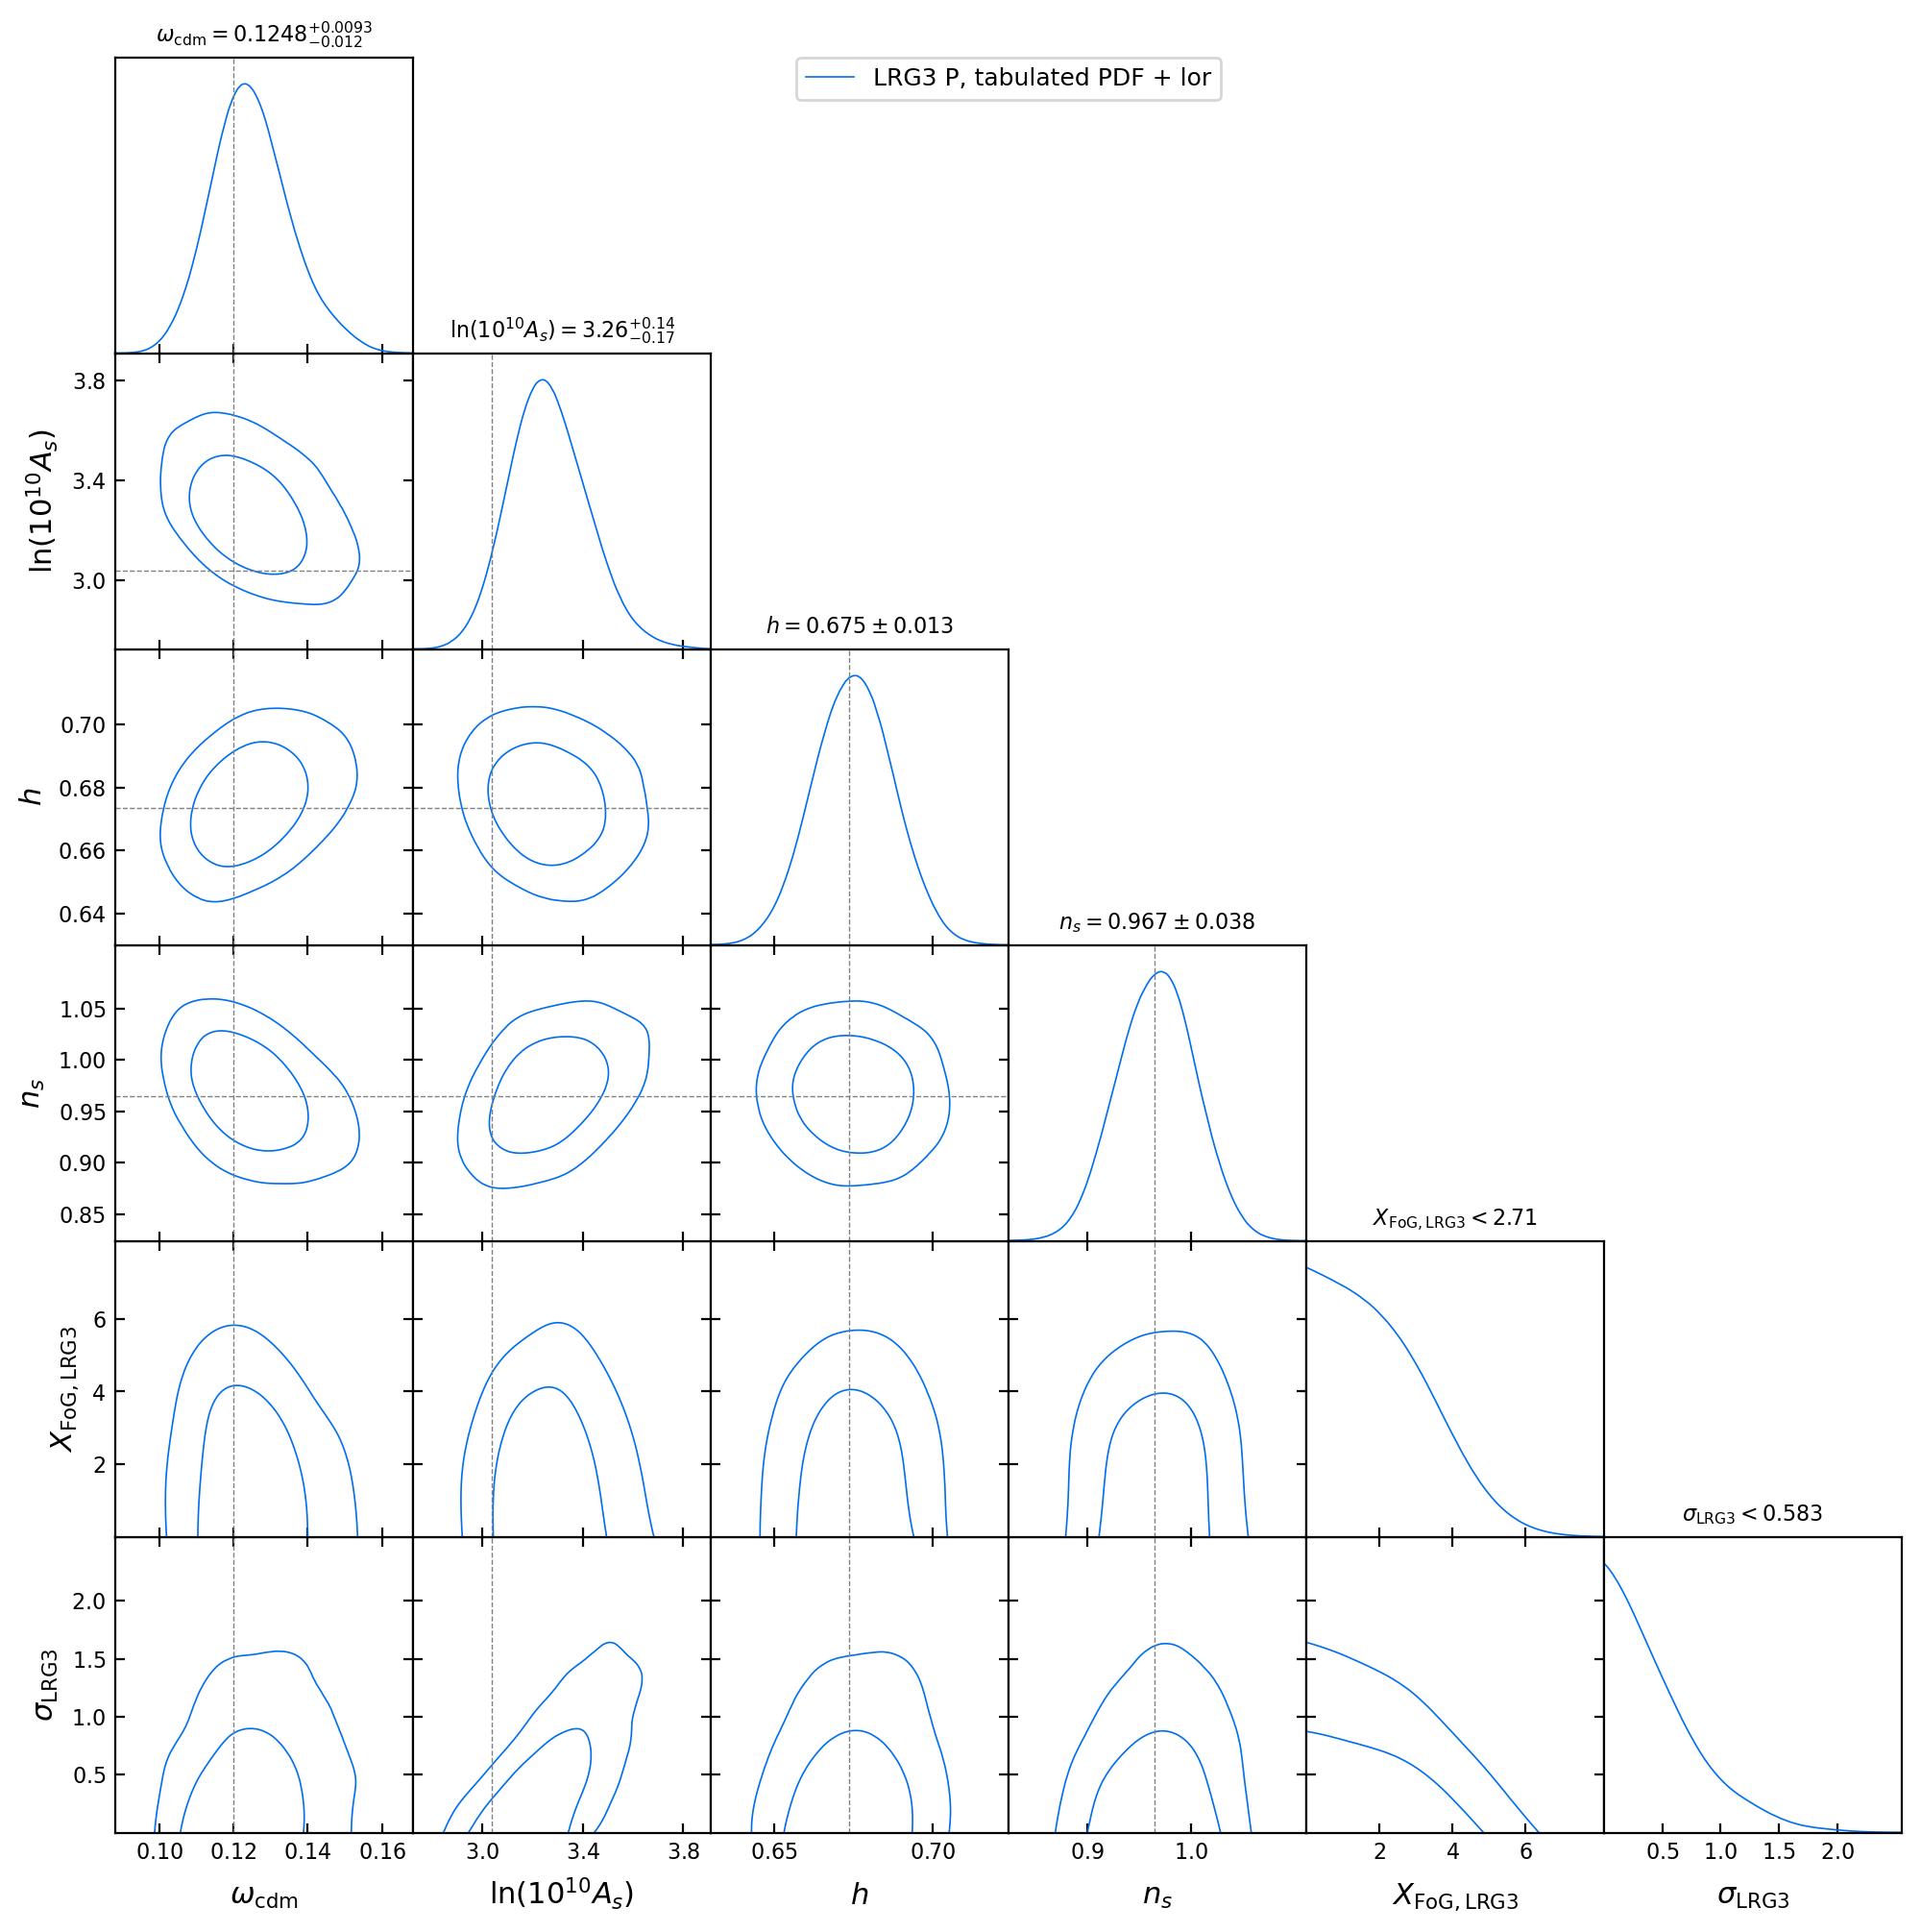

In [15]:
dirname = Path('/pscratch/sd/a/adematti/fits_redshift_smearing/abacus-hf-dr2-v2-altmtl')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_LRG3-S2-rs-pdf-lor-37a53648/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('LRG3 P, tabulated PDF + lor')
for sample in samples: sample['LRG3.vsmear'].update(latex=r'\sigma')
plotting.plot_triangle(samples, params=params_toplot + ['LRG3.vsmear'], title_limit=1, markers=truth, legend_labels=legends)
plt.show()

### QSO

Removed no burn in
Removed no burn in
Removed no burn in


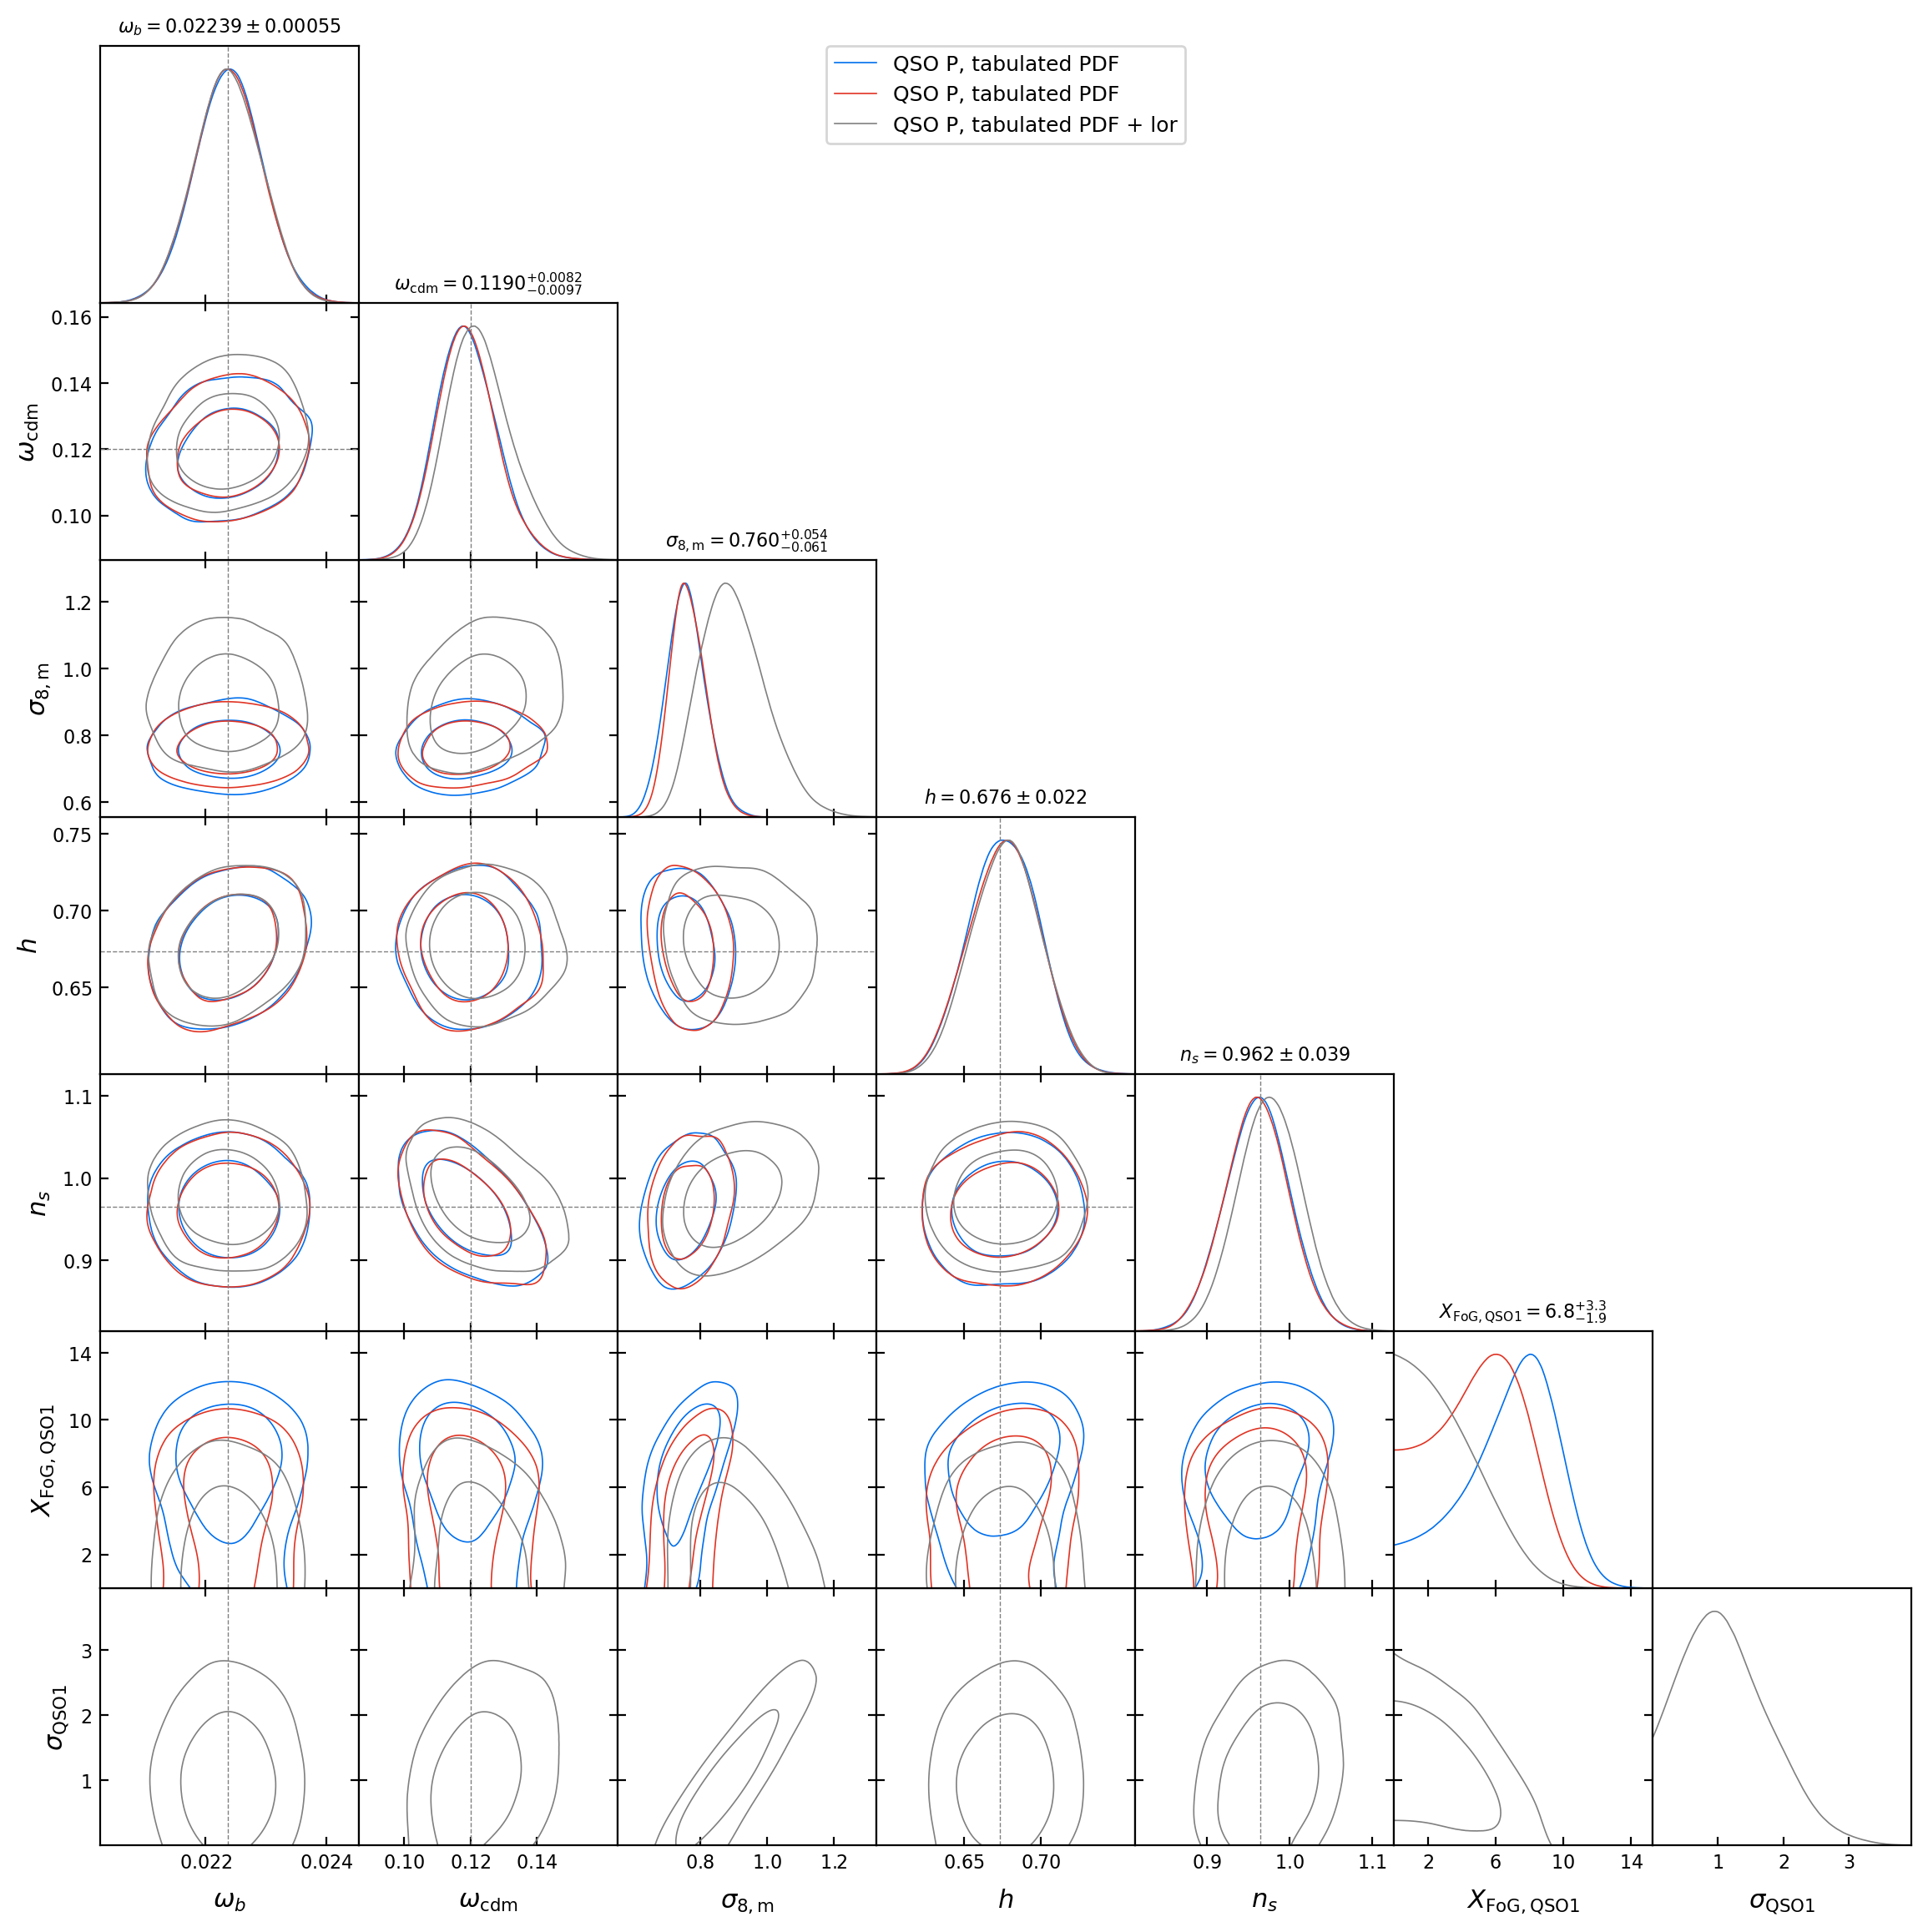

In [22]:
# P0 < 0.30, P2 < 0.20
dirname = Path('/pscratch/sd/a/adematti/fits_redshift_smearing/abacus-hf-dr2-v2-altmtl')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-eba36e08/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('QSO P, tabulated PDF')
samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-rs-pdf-225b47c3/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('QSO P, tabulated PDF')
samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-rs-pdf-lor-b7641f2d/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('QSO P, tabulated PDF + lor')
for sample in samples[-1:]: sample['QSO1.vsmear'].update(latex=r'\sigma')
plotting.plot_triangle(samples, params=params_toplot + ['QSO1.X_FoG', 'QSO1.vsmear'], title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

Removed no burn in
Removed no burn in


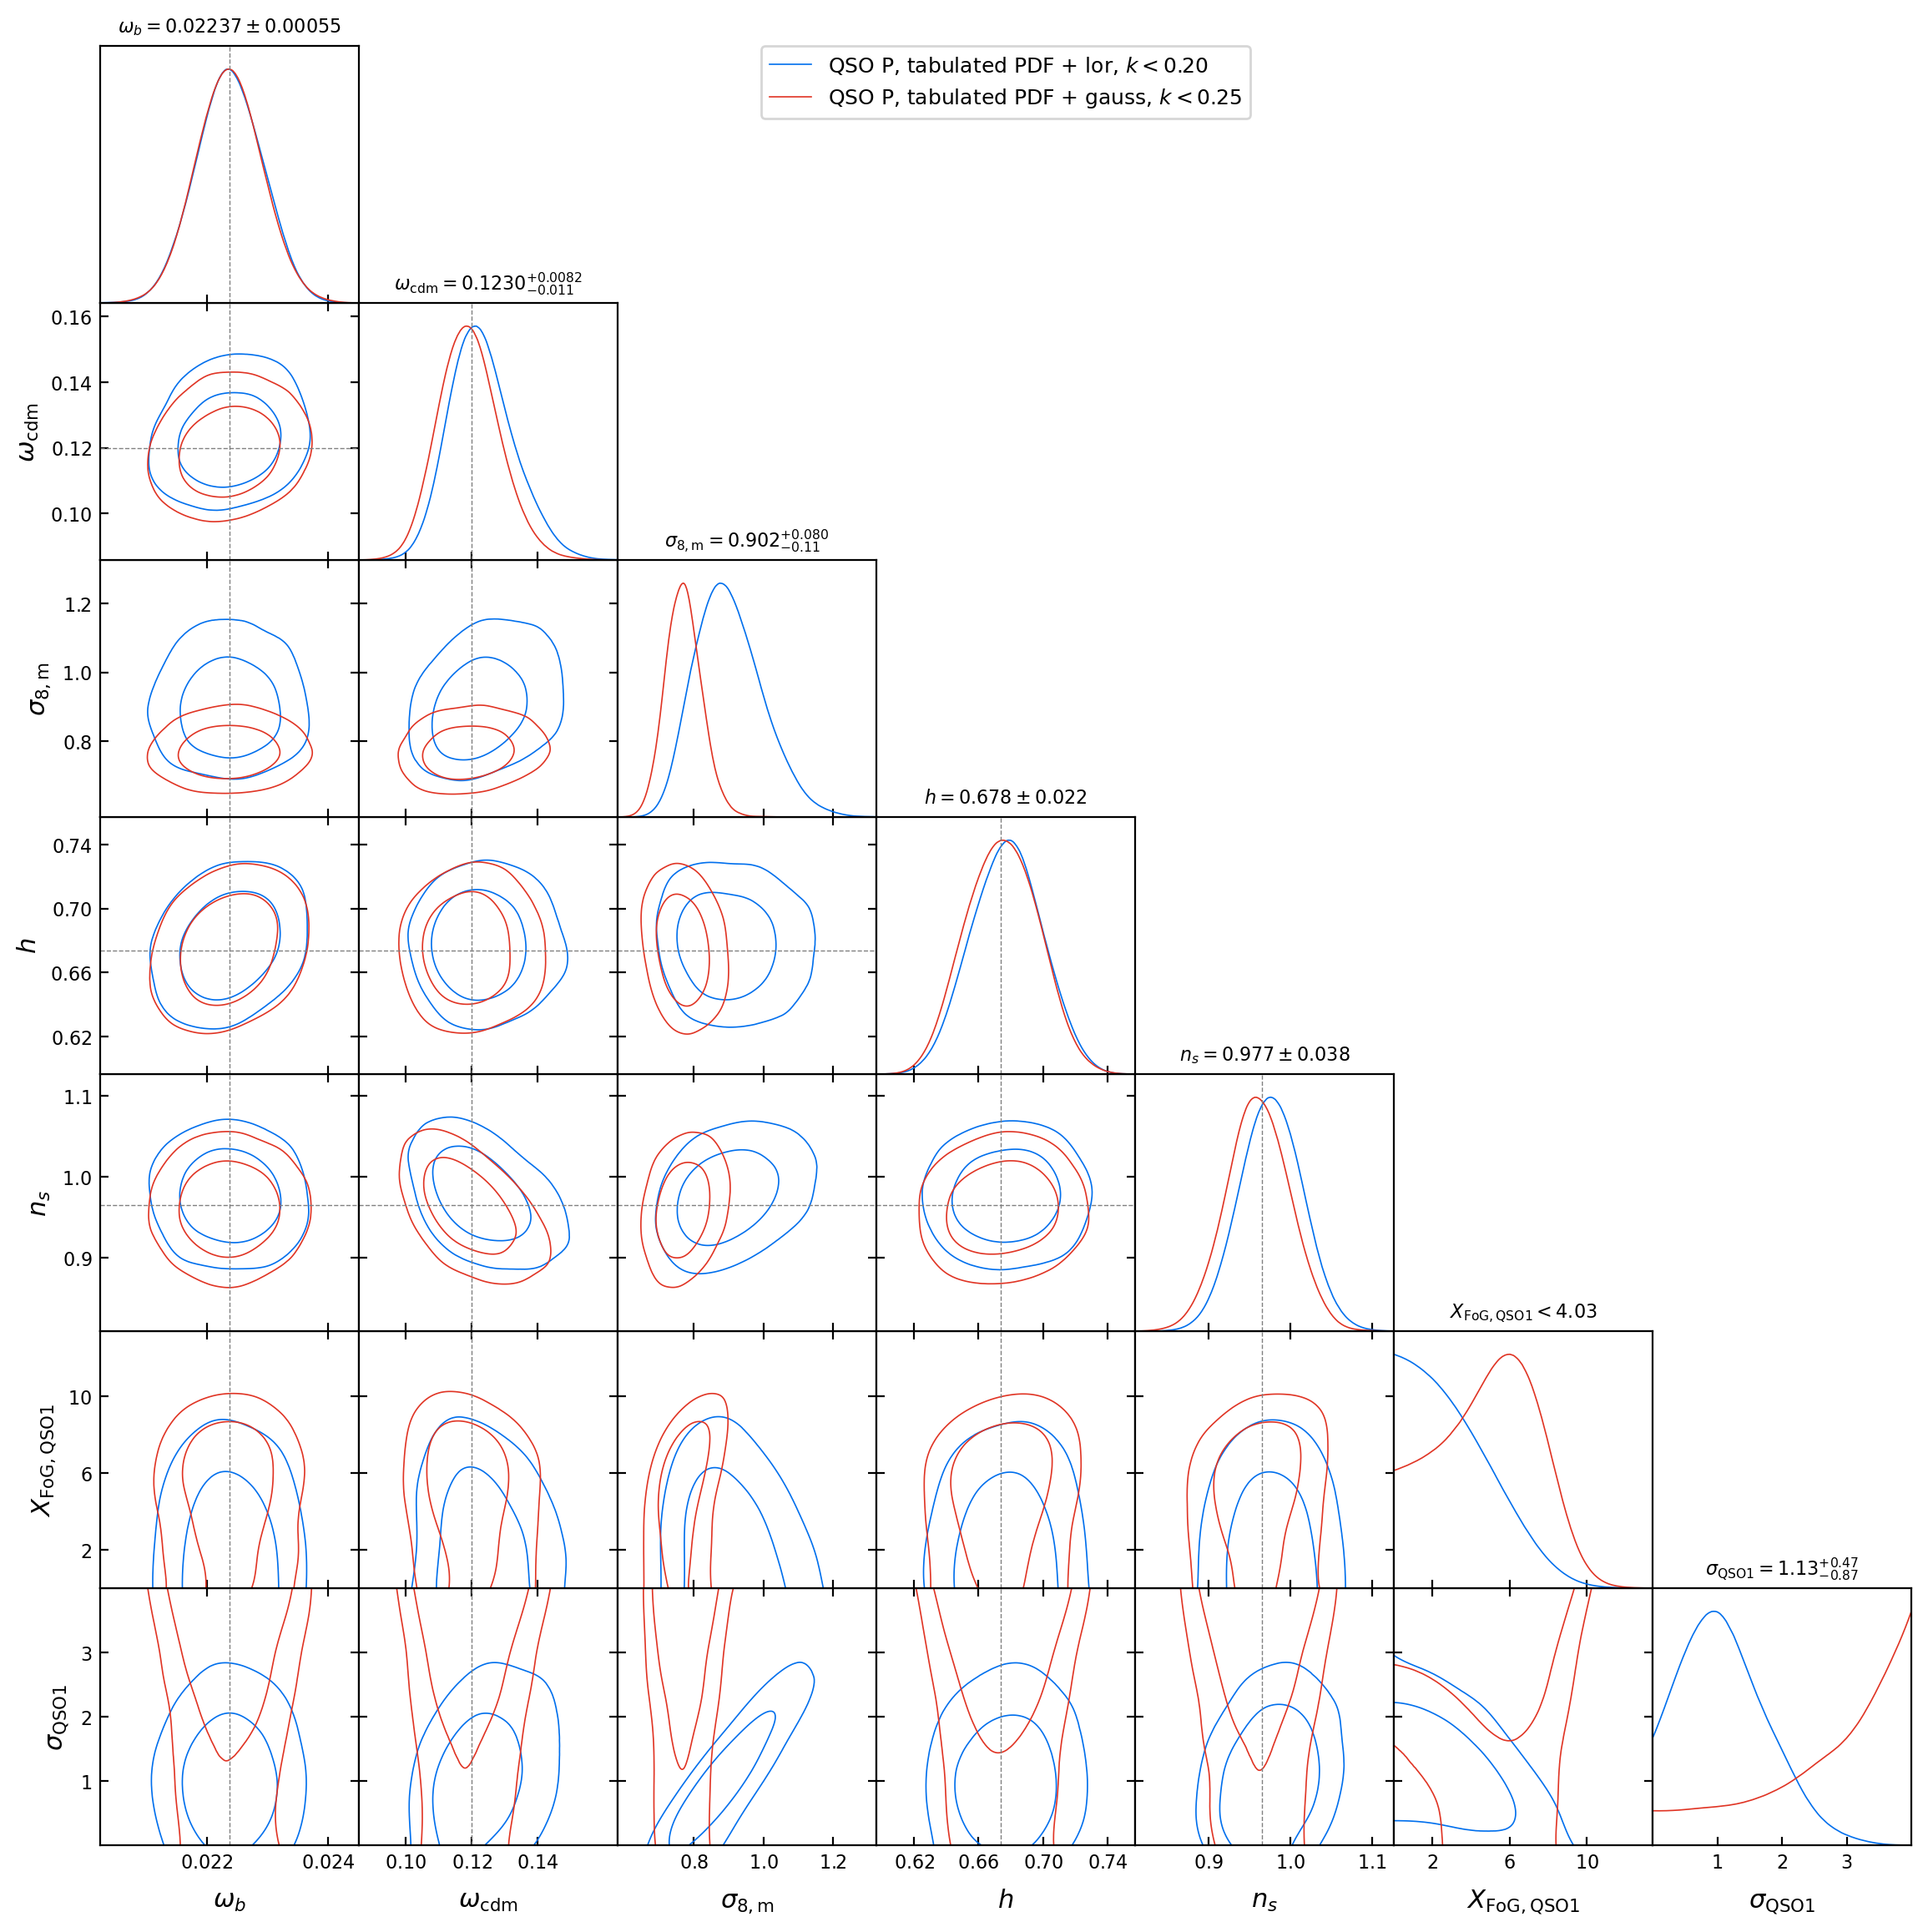

In [29]:
# P0 < 0.30, P2 < 0.20
dirname = Path('/pscratch/sd/a/adematti/fits_redshift_smearing/abacus-hf-dr2-v2-altmtl')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-rs-pdf-lor-b7641f2d/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('QSO P, tabulated PDF + lor, $k < 0.20$')
#samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-rs-pdf-lor-8ca78747/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
samples.append(read_samples([dirname / f'cosmo-base_QSO1-S2-rs-pdf-gauss-73d2efd1/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('QSO P, tabulated PDF + gauss, $k < 0.25$')
for sample in samples: sample['QSO1.vsmear'].update(latex=r'\sigma')
plotting.plot_triangle(samples, params=params_toplot + ['QSO1.X_FoG', 'QSO1.vsmear'], title_limit=1, markers=truth, legend_labels=legends)
plt.show()